# Microscopy Analysis

This notebook examines the effect of bead treatment on cell morphology using DIC microscopy images from three experimental formats: 96-well plates, test tubes, and 24-well plates. Single-cell measurements (area and major-axis length) are pooled across wells and replicates for each condition. Bar charts compare mean morphology with statistical comparisons made explicit using Holm-Bonferroni-corrected Welch's t-tests.

- **96-well**: Compares multiple bead sizes (0, 1, 1.5, 3, 4.5 mm) against a no-bead control.
- **Test tube & 24-well**: Compares bead vs. no-bead conditions across culture volumes (1–5 mL).

In [1]:
from pathlib import Path

import arcadia_pycolor as apc
import pandas as pd
from microscopy_helpers import (
    plot_metric_by_bead,
    plot_metric_by_volume,
    plot_metric_cross_experiment,
)

REPO_ROOT = Path().resolve().parent
apc.mpl.setup()

## Data preparation

Measurements are loaded from three CSVs under `data/microscopy/`. Each row represents a single segmented cell. For the 96-well experiment, treatment strings are mapped to numeric bead sizes. For test-tube and 24-well experiments, the `bead_present` column distinguishes bead from no-bead conditions and `volume_ml` gives the culture volume.

In [2]:
df_96 = pd.read_csv(REPO_ROOT / "data" / "microscopy" / "combined_dic_measurements_96well.csv")

treatment_to_bead_size = {
    "NO bead": 0.0,
    "1 mm bead": 1.0,
    "1.5 mm bead": 1.5,
    "3 mm bead": 3.0,
    "4.5 mm bead": 4.5,
}
df_96["bead_size_mm"] = df_96["treatment"].map(treatment_to_bead_size)

print(f"96-well: {len(df_96):,} cells")
df_96.sample(5, random_state=42).drop("source_file", axis=1)

96-well: 17,781 cells


,axis_major_length,area,length,well_letter,well_num,strain,treatment,bead_size_mm
8423,14.248126,41.589844,14.248126,A,8,SP286,4.5 mm bead,4.5
733,8.569660,29.310938,8.569660,A,1,SP286,1 mm bead,1.0
15122,7.161691,23.263906,7.161691,B,7,SP286,4.5 mm bead,4.5
9841,8.959319,28.149062,8.959319,A,10,SP286,NO bead,0.0
7792,9.155334,26.379844,9.155334,A,8,SP286,4.5 mm bead,4.5


In [3]:
df_tt = pd.read_csv(REPO_ROOT / "data" / "microscopy" / "combined_dic_measurements_ttubes.csv")
df_24 = pd.read_csv(REPO_ROOT / "data" / "microscopy" / "combined_dic_measurements_24well.csv")

print(f"Test tubes: {len(df_tt):,} cells")
df_tt.sample(5, random_state=42).drop("source_file", axis=1)

Test tubes: 41,742 cells


,axis_major_length,area,length,well_letter,well_num,strain,treatment,volume_ml,volume_group,bead_present
21388,19.181005,66.622969,19.181005,E,7,SP286,2 mL bead,2,b,True
40911,16.505401,57.143125,16.505401,F,10,SP286,5 mL bead,5,e,True
14084,10.688434,41.272969,10.688434,E,1,SP286,1 mL no bead,1,a,False
38362,12.400003,42.593281,12.400003,F,9,SP286,4 mL bead,4,d,True
29694,8.032724,29.126094,8.032724,F,2,SP286,2 mL no bead,2,b,False


In [4]:
print(f"24-well: {len(df_24):,} cells")
df_24.sample(5, random_state=42).drop("source_file", axis=1)

24-well: 42,648 cells


,axis_major_length,area,length,well_letter,well_num,strain,treatment,volume_ml,volume_group,bead_present
1900,13.528859,42.514063,13.528859,D,3,SP286,3 mL no bead,3,c,False
20628,11.552368,40.322344,11.552368,E,6,SP286,1 mL bead,1,a,True
33411,13.626529,49.749375,13.626529,F,5,SP286,5 mL no bead,5,e,False
40176,15.837376,57.882500,15.837376,F,9,SP286,4 mL bead,4,d,True
14421,8.744678,28.439531,8.744678,E,2,SP286,2 mL no bead,2,b,False


## 96-well experiment

Bar charts of mean cell area and length grouped by bead size. Error bars are approximate 95% confidence intervals (1.96 × SEM). Significance stars reflect Holm-Bonferroni-corrected Welch's t-tests against the no-bead control.

### Cell area

Mean cross-sectional area (μm²) per bead-size condition.

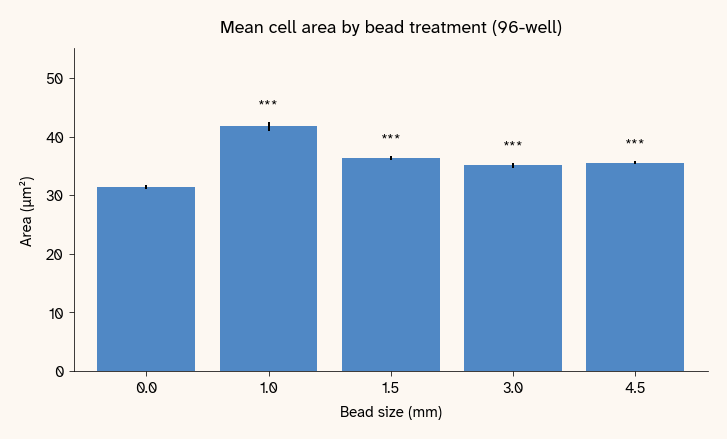

In [5]:
fig_96_area = plot_metric_by_bead(
    df_96, "area", REPO_ROOT / "figures" / "96-well_bar_plot_area.svg"
)

### Cell length

Mean major-axis length (μm) per bead-size condition.

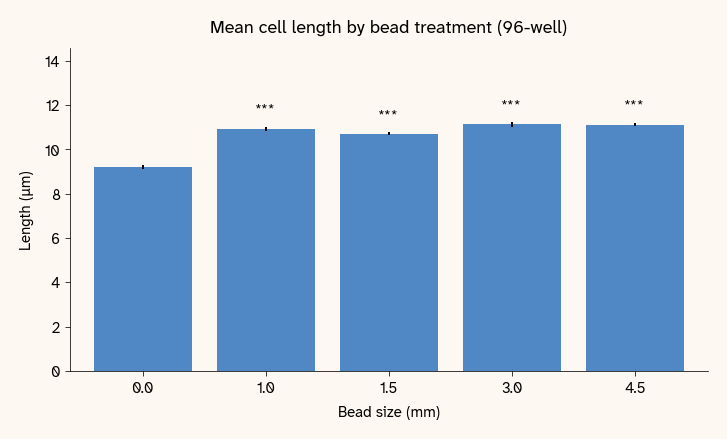

In [6]:
fig_96_length = plot_metric_by_bead(
    df_96, "length", REPO_ROOT / "figures" / "96-well_bar_plot_length.svg"
)

## Test tube experiment

Grouped bar charts of mean cell area and length by culture volume, comparing bead to no-bead conditions. Error bars are approximate 95% confidence intervals (1.96 × SEM). Significance stars reflect Holm-Bonferroni-corrected Welch's t-tests comparing bead to no-bead within each volume.

### Cell area

Mean cross-sectional area (μm²) per volume, comparing bead to no-bead conditions.

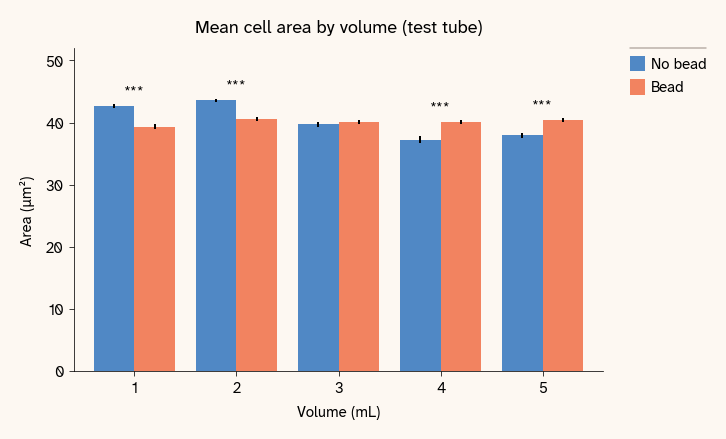

In [7]:
fig_tt_area = plot_metric_by_volume(
    df_tt, "area", "test tube", REPO_ROOT / "figures" / "ttube_bar_plot_area.svg"
)

### Cell length

Mean major-axis length (μm) per volume, comparing bead to no-bead conditions.

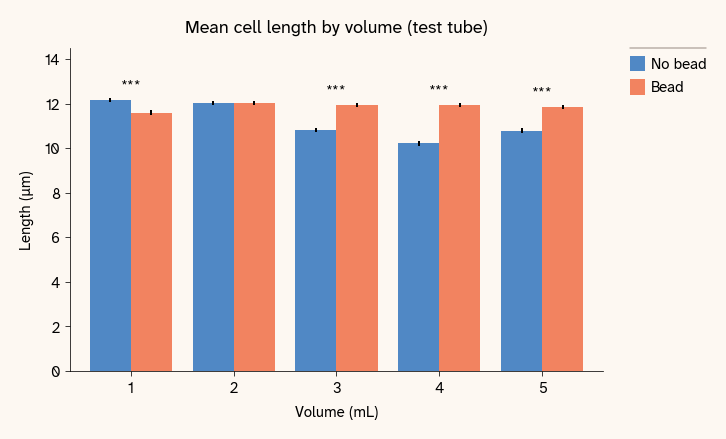

In [8]:
fig_tt_length = plot_metric_by_volume(
    df_tt, "length", "test tube", REPO_ROOT / "figures" / "ttube_bar_plot_length.svg"
)

## 24-well experiment

Grouped bar charts of mean cell area and length by culture volume, comparing bead to no-bead conditions. Error bars are approximate 95% confidence intervals (1.96 × SEM). Significance stars reflect Holm-Bonferroni-corrected Welch's t-tests comparing bead to no-bead within each volume.

### Cell area

Mean cross-sectional area (μm²) per volume, comparing bead to no-bead conditions.

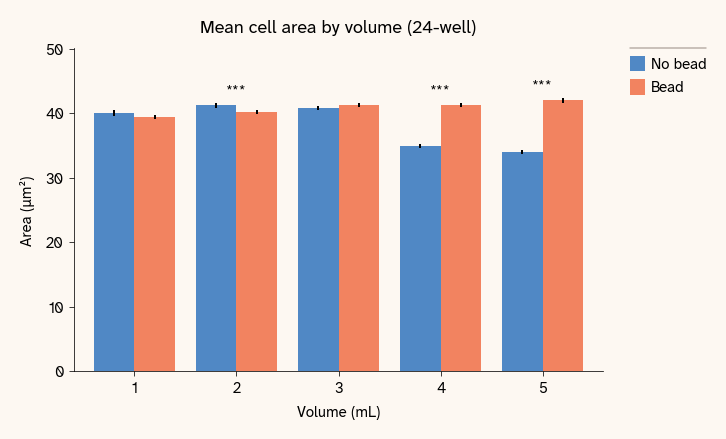

In [9]:
fig_24_area = plot_metric_by_volume(
    df_24, "area", "24-well", REPO_ROOT / "figures" / "24-well_bar_plot_area.svg"
)

### Cell length

Mean major-axis length (μm) per volume, comparing bead to no-bead conditions.

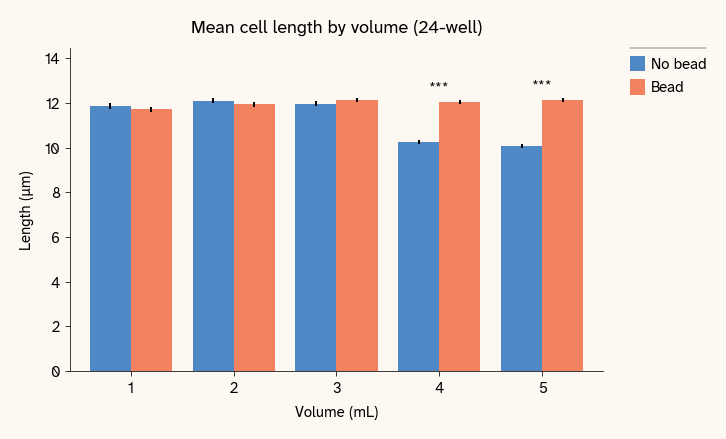

In [10]:
fig_24_length = plot_metric_by_volume(
    df_24, "length", "24-well", REPO_ROOT / "figures" / "24-well_bar_plot_length.svg"
)

## Cross-experiment comparison

Line plots of mean cell area and length vs. culture volume, overlaying all three experiments. The 96-well experiment is shown as a single point at 1 mL. Shaded bands (or error bars for single points) indicate approximate 95% confidence intervals.

In [11]:
df_agg = pd.concat([
    df_96.assign(volume_ml=1, bead_present=df_96["bead_size_mm"] > 0, experiment="96-well"),
    df_tt.assign(experiment="test tube"),
    df_24.assign(experiment="24-well"),
])

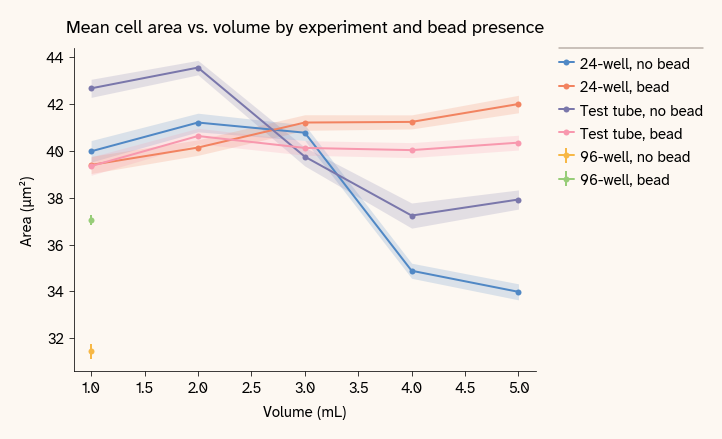

In [12]:
fig_cross_area = plot_metric_cross_experiment(
    df_agg, "area", REPO_ROOT / "figures" / "agg_line_plot_area.svg"
)

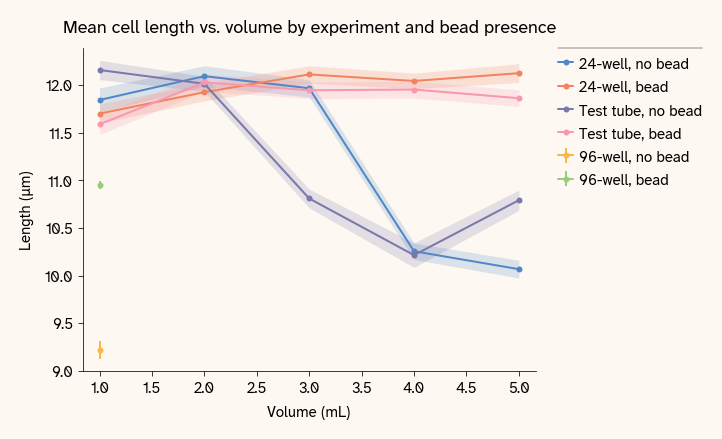

In [13]:
fig_cross_length = plot_metric_cross_experiment(
    df_agg, "length", REPO_ROOT / "figures" / "agg_line_plot_length.svg"
)